In [7]:
"""Accuracy vs. transition budget (base style) for each model, one line per dataset."""

import json
from pathlib import Path

import matplotlib.pyplot as plt

In [8]:
# --- configuration ---

OUTPUT_DIR = Path("../output")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# models to compare: display name → results json filename
MODELS: dict[str, str] = {
    "Qwen3-8B": "qwen3-8b.json",
    "OLMo-3-7B-Think": "olmo-3-7b-think.json",
    "Code-Nemotron-7B": "code-nemotron-7b.json",
}

# benchmarks to plot, in display order: display label → key prefix in results files
DATASETS: dict[str, str] = {
    "EvalPlus": "code/evalplus_greedy",
    "LiveCodeBench": "code/livecodebench_greedy",
    "BigCodeBench": "code/bigcodebench_greedy",
    "CRUXEval-I": "crux/cruxeval_i_greedy",
    "CRUXEval-O": "crux/cruxeval_o_greedy",
    "GSM8K": "math/gsm8k_greedy",
    "MATH-500": "math/math500_greedy",
    "GPQA": "reasoning/gpqa_greedy",
}

# human-readable labels for token budget sizes on the x-axis
BUDGET_LABELS: dict[int, str] = {
    4096: "4K",
    8192: "8K",
    12288: "12K",
    16384: "16K",
    20480: "20K",
    24576: "24K",
    28664: "28K",
}

# one distinct colour per model (tab10 palette)
MODEL_COLOURS: dict[str, str] = {
    model: f"C{i}" for i, model in enumerate(MODELS)
}

In [9]:
def load_model_data(
    results_path: Path,
) -> dict[str, dict]:
    """Load base-style accuracy data for all available datasets in one model file.

    For each dataset prefix present in the file the function collects every
    base-style entry (keys ending in `_mt{budget}_base`) and the unconstrained
    baseline entry (key ending in `_baseline`) if it exists.

    Returns a dict: dataset_label → {"budgets": [...], "accuracies": [...], "baseline": float | None}
    """
    with open(results_path) as f:
        results = json.load(f)

    data: dict[str, dict] = {}
    for label, prefix in DATASETS.items():
        # collect all base-style keys for this dataset prefix
        base_keys = [
            k for k in results
            if k.startswith(prefix) and k.endswith("_base")
        ]
        if not base_keys:
            # dataset not present in this model's results file
            continue

        # extract budget → accuracy pairs and sort by budget
        budget_acc: list[tuple[int, float]] = []
        for key in base_keys:
            # key format: {prefix}_mt{budget}_base
            budget = int(key.split("_mt")[1].split("_base")[0])
            budget_acc.append((budget, results[key]["pass_at_1"]))
        budget_acc.sort(key=lambda x: x[0])

        # load unconstrained baseline accuracy if available
        baseline_key = prefix + "_baseline"
        baseline = results[baseline_key]["pass_at_1"] if baseline_key in results else None

        data[label] = {
            "budgets": [b for b, _ in budget_acc],
            "accuracies": [a for _, a in budget_acc],
            "baseline": baseline,
        }

    return data

In [10]:
def plot_all_models_per_benchmark(
    all_model_data: dict[str, dict[str, dict]],
    save_path: Path,
) -> None:
    """Plot all models together on one figure, one subplot per benchmark.

    Subplots are arranged in two columns. Each subplot shows one line per model
    (accuracy vs. transition budget). Where a baseline exists for a model on that
    benchmark it is drawn as a dashed horizontal line in the same model colour.
    The y-axis is zoomed to the data range so small differences are visible.
    Saves the combined figure as a PNG.
    """
    n_datasets = len(DATASETS)
    n_cols = 2
    n_rows = (n_datasets + 1) // n_cols

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(12, 4 * n_rows),
    )
    fig.suptitle(
        "Accuracy vs. Transition Budget (base style)",
        fontsize=14,
        fontweight="bold",
        y=1.01,
    )

    # flatten so we can index by position regardless of n_rows
    flat_axes = axes.flatten()

    for ax, dataset_label in zip(flat_axes, DATASETS):
        # track all y-values to set a zoomed y-axis range after drawing
        all_vals: list[float] = []

        for model_name, model_data in all_model_data.items():
            if dataset_label not in model_data:
                # this benchmark was not run for this model
                continue

            ds_data = model_data[dataset_label]
            colour = MODEL_COLOURS[model_name]
            budgets = ds_data["budgets"]
            accuracies = [a * 100 for a in ds_data["accuracies"]]
            all_vals.extend(accuracies)

            # main line: accuracy at each transition budget
            ax.plot(
                budgets,
                accuracies,
                marker="o",
                markersize=5,
                linewidth=2,
                color=colour,
                label=model_name,
            )

            # dashed horizontal baseline in the same model colour where available
            if ds_data["baseline"] is not None:
                baseline_pct = ds_data["baseline"] * 100
                all_vals.append(baseline_pct)
                ax.axhline(
                    y=baseline_pct,
                    color=colour,
                    linewidth=1.2,
                    linestyle="--",
                    alpha=0.5,
                )

        ax.set_title(dataset_label, fontsize=11, fontweight="bold")
        ax.set_xlabel("Transition budget (tokens)")
        ax.set_ylabel("Accuracy (pass@1 %)")

        # collect all budget ticks across every model for this benchmark
        all_budgets = sorted({
            b
            for model_data in all_model_data.values()
            if dataset_label in model_data
            for b in model_data[dataset_label]["budgets"]
        })
        ax.set_xticks(all_budgets)
        ax.set_xticklabels([BUDGET_LABELS.get(b, str(b)) for b in all_budgets])

        # zoom y-axis so differences are easy to read
        if all_vals:
            margin = max(1.0, (max(all_vals) - min(all_vals)) * 0.2)
            ax.set_ylim(
                max(0.0, min(all_vals) - margin),
                min(100.0, max(all_vals) + margin),
            )

        ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(fontsize=8, frameon=False)

    # hide the spare axes when n_datasets is odd
    for ax in flat_axes[n_datasets:]:
        ax.set_visible(False)

    plt.tight_layout()
    fig.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight",
    )
    print(f"saved → {save_path}")
    plt.show()

saved → ../figures/03_transition_accuracy.png


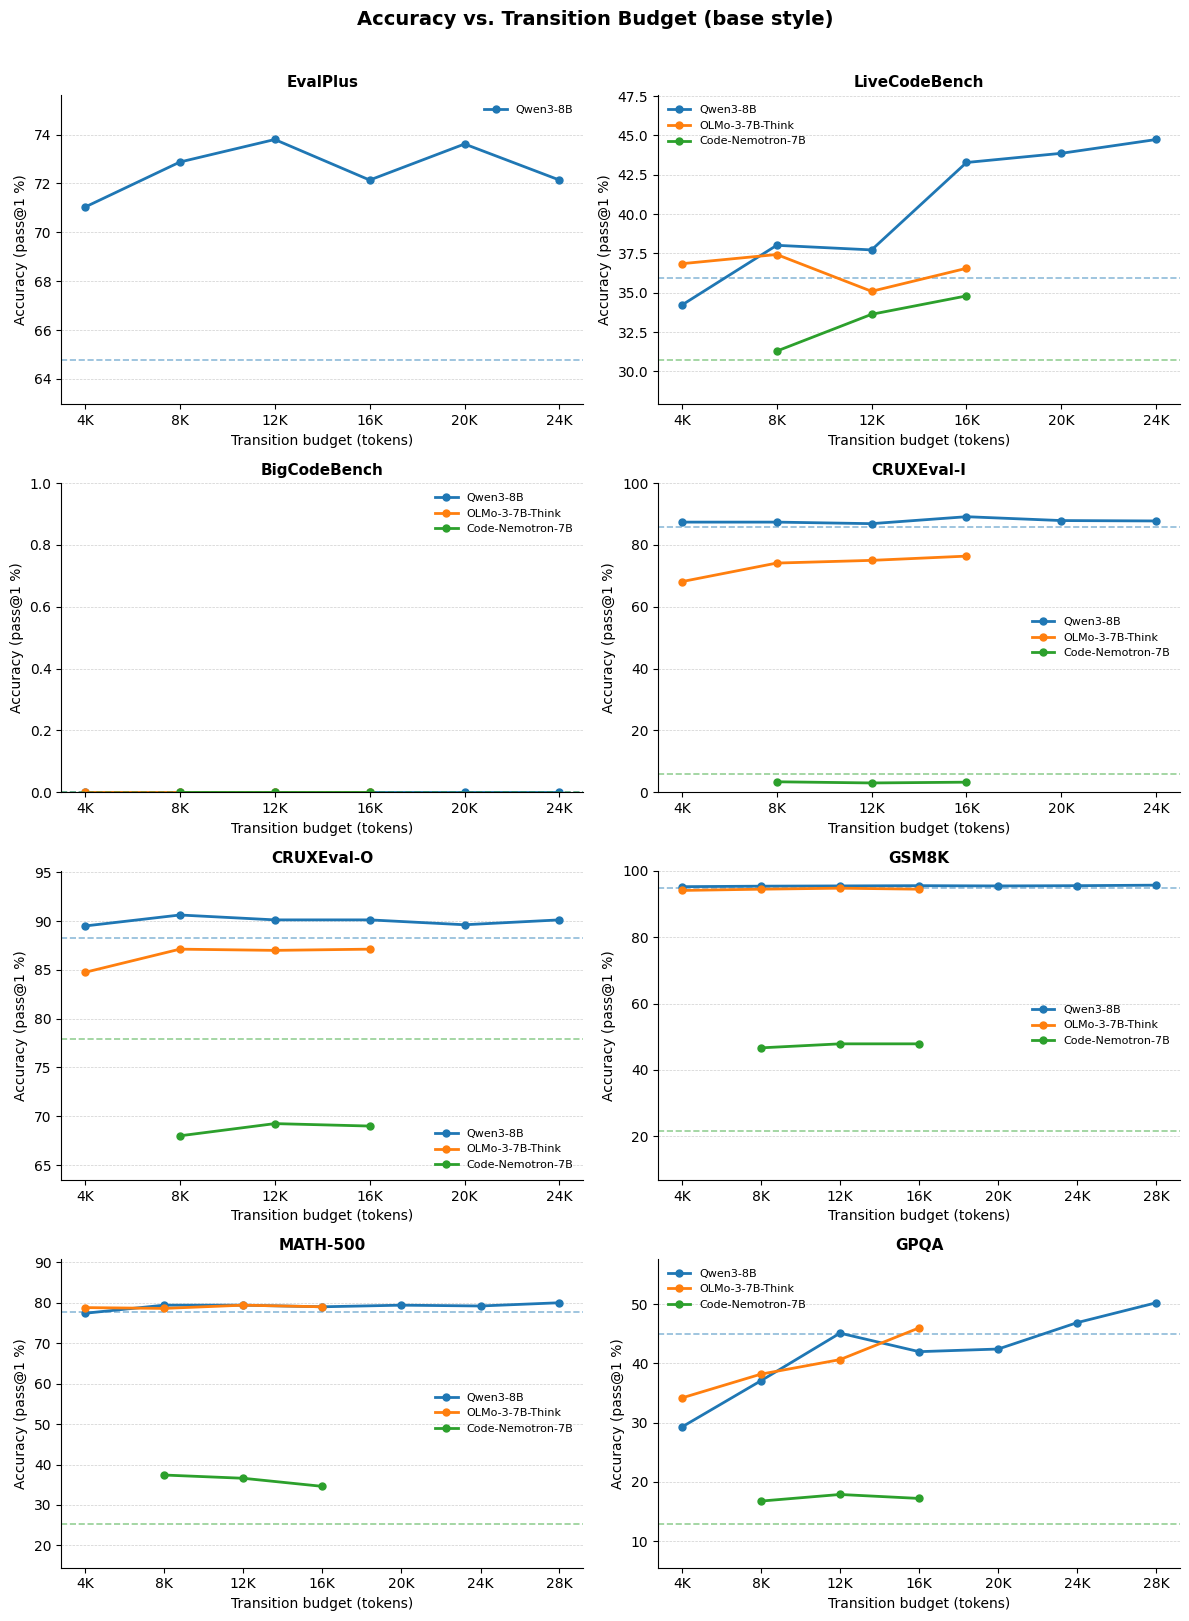

In [11]:
# load data for all models then produce the combined figure
all_model_data = {
    model_name: load_model_data(OUTPUT_DIR / filename)
    for model_name, filename in MODELS.items()
}

plot_all_models_per_benchmark(
    all_model_data=all_model_data,
    save_path=FIGURES_DIR / "03_transition_accuracy.png",
)